In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.metrics import accuracy_score

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

FEATURES_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "advanced_audio_features.csv"
)

df = pd.read_csv(
    FEATURES_PATH
)

df.shape

(520, 40)

In [3]:
feature_columns = [

    col

    for col in df.columns

    if col not in [
        "filename",
        "category"
    ]
]

X = df[
    feature_columns
]

y = df["category"]

In [4]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(
    y
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [7]:
models = {

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf",
            C=1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

In [8]:
results = {}

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    preds = model.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        preds
    )

    results[name] = acc

    print(
        name,
        "->",
        round(acc,4)
    )

Random Forest -> 0.7212
KNN -> 0.5673
SVM -> 0.6635
Gradient Boosting -> 0.6058


In [9]:
results_df = pd.DataFrame({

    "Model":
        results.keys(),

    "Accuracy":
        results.values()
})

results_df

,Model,Accuracy
0,Random Forest,0.721154
1,KNN,0.567308
2,SVM,0.663462
3,Gradient Boosting,0.605769


In [10]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
0,Random Forest,0.721154
2,SVM,0.663462
3,Gradient Boosting,0.605769
1,KNN,0.567308


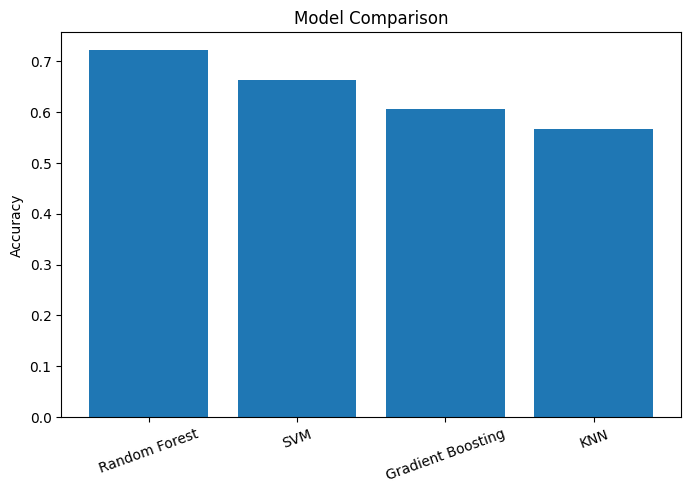

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Model Comparison"
)

plt.xticks(rotation=20)

plt.show()